In [1]:
import pandas as pd
import numpy as np
import os
import pickle

os.chdir('../..')


In [2]:
os.getcwd()

'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

In [4]:
seqImpact = pd.read_csv('output/data/sanityCheck/seqImpact_predictions.csv') # checks the impact of the sequences on predictions (extraFeatures the extraFeatImpact for all sequences)
extraFeatImpact = pd.read_csv('output/data/sanityCheck/extraFeatImpact_predictions.csv') # checks the impact of the extraFeatures on predictions (sequence the extraFeatImpact for all extraFeatures)
utr5Impact = pd.read_csv('output/data/sanityCheck/5UTRImpact_predictions.csv') # checks the impact of the 3' UTR on predictions (5' UTR and extraFeatures the extraFeatImpact for all while 3' UTR are the seqImpactinals)
utr3Impact = pd.read_csv('output/data/sanityCheck/3UTRImpact_predictions.csv') # checks the impact of the 5' UTR on predictions (3' UTR and extraFeatures the extraFeatImpact for all while 5' UTR are the seqImpactinals)

# # merge the two dataframes on sequenceCounts
# merged = pd.merge(seqImpact, extraFeatImpact, on='sequenceCount', suffixes=('_seqImpact', '_extraFeatImpact'), how='outer')
# # Add suffix to utr5Impact columns before merging to avoid naming conflicts
# utr5Impact = utr5Impact.add_suffix('_utr5Impact')
# utr5Impact = utr5Impact.rename(columns={'sequenceCount_utr5Impact': 'sequenceCount'})
# merged = pd.merge(merged, utr5Impact, on='sequenceCount', how='outer')
# merged = pd.merge(merged, utr3Impact, on='sequenceCount', suffixes=('', '_utr3Impact'), how='outer')

In [5]:
print(seqImpact)
print(extraFeatImpact)
print(utr5Impact)
print(utr3Impact)

          originalPrediction  perturbedPrediction  sequenceCount
0                       0.36                 0.82              1
1                       0.36                 0.58              2
2                       0.36                 0.81              3
3                       0.36                 0.61              4
4                       0.36                 0.30              5
...                      ...                  ...            ...
17745151                0.30                 0.29       17745152
17745152                0.30                 0.43       17745153
17745153                0.30                 0.31       17745154
17745154                0.30                 0.29       17745155
17745155                0.30                 0.36       17745156

[17745156 rows x 3 columns]
          originalPrediction  perturbedPrediction  sequenceCount
0                       0.36                 0.36              1
1                       0.36                 0.49            

In [6]:
print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean(abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction'])):.4f}")

print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean(abs(extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction'])):.4f}")


print("\n(impact of 5UTR) :")
print(f"  {np.mean(abs(utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean(abs(utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction'])):.4f}")


(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1201
(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1048

(impact of 5UTR) :
  0.0752

(impact of 3UTR) :
  0.0840


In [9]:
print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean((seqImpact['originalPrediction'] - seqImpact['perturbedPrediction'])):.4f}")

print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean((extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction'])):.4f}")


print("\n(impact of 5UTR) :")
print(f"  {np.mean((utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean((utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction'])):.4f}")


(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.0018
(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.0017

(impact of 5UTR) :
  0.0123

(impact of 3UTR) :
  0.0125


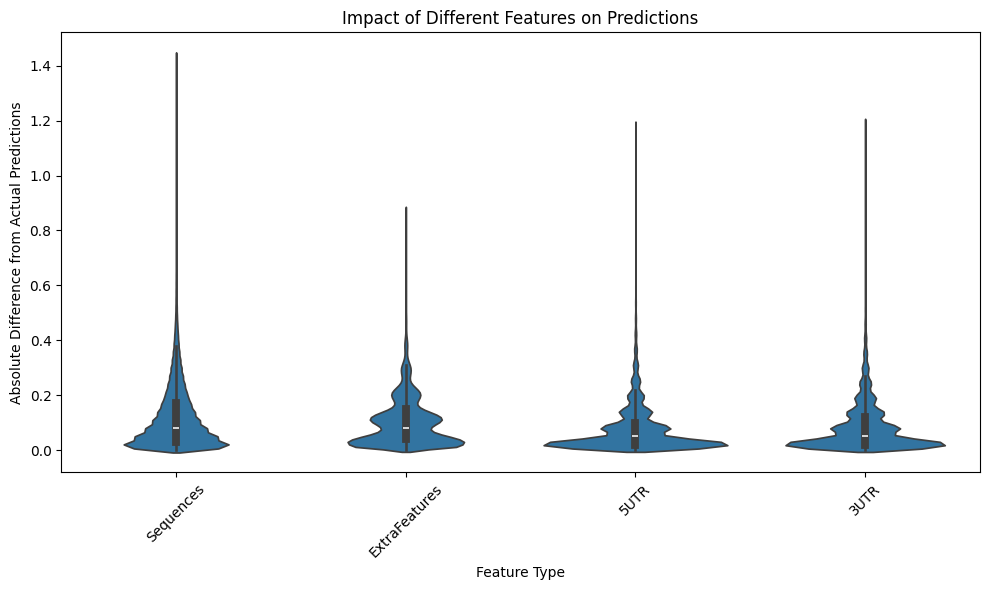

In [7]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_sequences = abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction']).dropna()
impact_extraFeatures = abs(extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction']).dropna()
impact_5UTR = abs(utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction']).dropna()
impact_3UTR = abs(utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_sequences) + list(impact_extraFeatures) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['Sequences'] * len(impact_sequences) + 
               ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

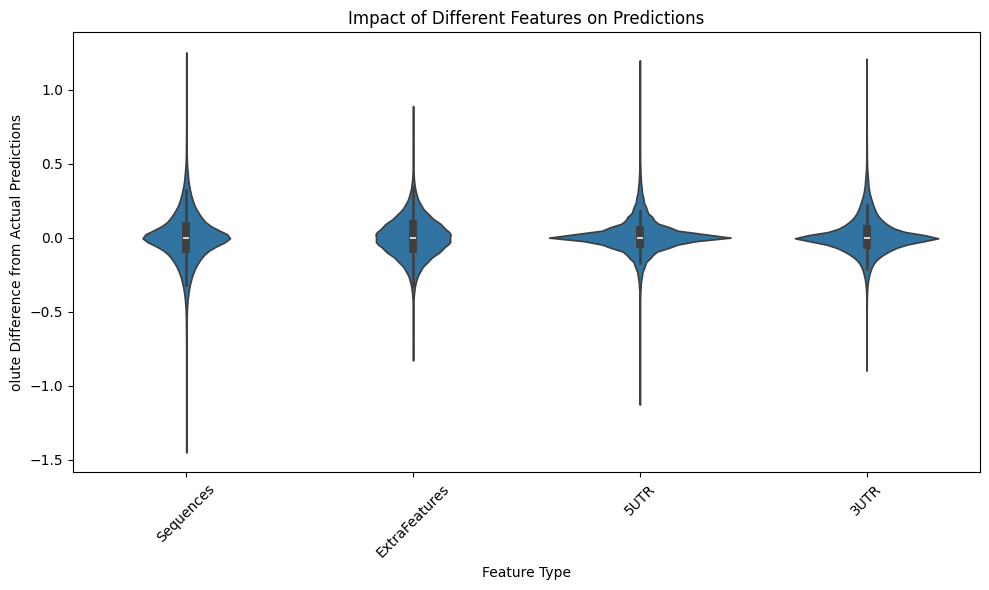

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_sequences = (seqImpact['originalPrediction'] - seqImpact['perturbedPrediction']).dropna()
impact_extraFeatures = (extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction']).dropna()
impact_5UTR = (utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction']).dropna()
impact_3UTR = (utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_sequences) + list(impact_extraFeatures) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['Sequences'] * len(impact_sequences) + 
               ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('olute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# Calculate impacts (reusing the calculations from cell 13 but with absolute values)
impact_sequences = abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction']).dropna()
impact_extraFeatures = abs(extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction']).dropna()
impact_5UTR = abs(utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction']).dropna()
impact_3UTR = abs(utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction']).dropna()

# Store impacts in a dictionary for easier access
impacts = {
    'ExtraFeatures': impact_extraFeatures,
    'Sequences': impact_sequences,
    '5UTR': impact_5UTR,
    '3UTR': impact_3UTR
}

# Kruskal-Wallis test (non-parametric ANOVA)
print("Kruskal-Wallis Test (overall significance):")
h_stat, p_value = kruskal(*impacts.values())
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

print("\n" + "="*50)
print("Pairwise Mann-Whitney U Tests:")
print("="*50)

# Pairwise comparisons using Mann-Whitney U test
feature_names = list(impacts.keys())
for i, feature1 in enumerate(feature_names):
    for j, feature2 in enumerate(feature_names[i+1:], i+1):
        u_stat, p_val = mannwhitneyu(impacts[feature1], impacts[feature2], alternative='two-sided')
        print(f"{feature1} vs {feature2}:")
        print(f"  U-statistic: {u_stat:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
        print()

Kruskal-Wallis Test (overall significance):
H-statistic: 2978963.4331
p-value: 0.0000
Significant: Yes

Pairwise Mann-Whitney U Tests:
ExtraFeatures vs Sequences:
  U-statistic: 155673054901295.5000
  p-value: 0.0000
  Significant: Yes

ExtraFeatures vs 5UTR:
  U-statistic: 201890457708820.5000
  p-value: 0.0000
  Significant: Yes

ExtraFeatures vs 3UTR:
  U-statistic: 190537734346447.5000
  p-value: 0.0000
  Significant: Yes

Sequences vs 5UTR:
  U-statistic: 199877978589500.0000
  p-value: 0.0000
  Significant: Yes

Sequences vs 3UTR:
  U-statistic: 189575736402044.0000
  p-value: 0.0000
  Significant: Yes

5UTR vs 3UTR:
  U-statistic: 148998155482865.5000
  p-value: 0.0000
  Significant: Yes



In [11]:
p_value

0.0

In [4]:
merged

,originalPrediction_seqImpact,perturbedPrediction_seqImpact,sequenceCount,originalPrediction_extraFeatImpact,perturbedPrediction_extraFeatImpact,originalPrediction,perturbedPrediction,originalPrediction_utr3Impact,perturbedPrediction_utr3Impact
0,0.36,0.82,1,NaN,NaN,0.36,0.45,0.36,0.34
1,0.36,0.58,2,NaN,NaN,0.36,0.41,0.36,0.33
2,0.36,0.81,3,NaN,NaN,0.36,0.39,0.36,0.34
3,0.36,0.61,4,NaN,NaN,0.36,0.38,0.36,0.35
4,0.36,0.30,5,NaN,NaN,0.36,0.37,0.36,0.32
...,...,...,...,...,...,...,...,...,...
17871540,NaN,NaN,17858579,NaN,NaN,NaN,NaN,0.33,0.32
17871541,NaN,NaN,17858652,NaN,NaN,NaN,NaN,0.33,0.33
17871542,NaN,NaN,17861577,NaN,NaN,NaN,NaN,0.37,0.40
17871543,NaN,NaN,17865819,NaN,NaN,NaN,NaN,0.40,0.38


In [ ]:
#importance = pickle.load(open('output/importance/shap.pkl', 'rb'))


In [ ]:
#importance[0]

Explanation(text='0.34 Pred:0.36', tokens=['', 'TCG', 'ATACTATC', 'GCG', 'AGTGC', 'TAGCTGAC', 'GCTGG', 'TCTGG', 'TTTTATT', 'TTATG', 'TTAAC', 'GGG', 'AGTGATC', 'TTGCG', 'TACAAAC', 'AATAAC', 'ACGG', 'AATCGC', 'AGTGAA', 'AGGGCG', 'TTGCACAA', 'ATGACAGTG', 'TTTTGGC', 'AAAATGCCC', 'GGGC', 'TAGTTTTG', 'ACCACG', 'TTTAGC', 'AGTGCC', 'TAGAAC', 'GC', 'AGAGTGC', 'GCG', 'ACGC', 'TAAAAC', 'AAG', 'AGAACC', 'GCG', 'ACAAAAC', 'AAAAC', 'GCGG', 'AAACGC', 'ATAAAGTG', 'AAAAAAAA', 'AACAC', 'AAACGC', 'AGACAGCG', 'AACTTTGG', 'ACACAGAC', 'AATCG', 'TAAACGC', 'ACGGGG', 'AAAAC', 'AAAGAAAA', 'ACG', 'AAGAA', '[SEP]', 'GCGG', 'AATAA', 'TGCC', 'TCTAG', 'TTATG', 'TCATT', 'AGTTAG', 'TTTTTATT', 'TATGG', 'AAGGGC', 'GG', 'TCAATATGG', 'AGAG', 'AGGCAGGG', 'ACAAAC', 'TAAAATATC', 'AAGGACG', 'ACTTTAG', 'AAAGATTGC', 'TTGGG', 'AAAGTAA', 'AGGTC', 'TTAAG', 'TTC', 'AGCATT', 'TCTC', 'TCATCC', 'TTTTAAAA', 'TCAGTTTTC', 'AGTTATG', 'TATTTCG', 'ATT', 'AGATAAGG', 'AATG', 'TAAGATC', 'AGATT', 'TTACTGC', 'ATAA', 'TGTTTAT', 'ATGTCTTTT', 'TAAA

In [6]:
counts = [x+1 for x in range(len(importance))]
actualPredictions = [imp.text.split(' ')[1].split(':')[1] for imp in importance]

ap = pd.DataFrame({'sequenceCount': counts, 'actualPredictions': actualPredictions})

# merge combined with ap
merged_df = pd.merge(ap, merged, on='sequenceCount', suffixes=('_ap',''), how='outer')

In [7]:
merged_df

,sequenceCount,actualPredictions,actualDecayRate_orig,predictedDecayRate_orig,actualDecayRate_same,predictedDecayRate_same,actualDecayRate,predictedDecayRate,actualDecayRate_utr3,predictedDecayRate_utr3
0,1,0.36,0.53,0.39,0.53,0.39,0.53,0.39,0.53,0.39
1,2,0.85,0.53,0.39,0.62,0.52,0.53,0.35,0.53,0.40
2,3,0.72,0.53,0.52,0.72,0.37,0.53,0.53,0.53,0.43
3,4,0.75,0.53,0.53,0.37,0.56,0.53,0.56,0.53,0.39
4,5,0.74,0.53,0.66,0.75,0.46,0.53,0.57,0.53,0.45
...,...,...,...,...,...,...,...,...,...,...
4208,4209,0.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4209,4210,0.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4210,4211,0.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4211,4212,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print(merged_df[['actualPredictions','predictedDecayRate_orig','predictedDecayRate_same','predictedDecayRate','predictedDecayRate_utr3']].to_numpy().T)

[['0.36' '0.85' '0.72' ... '0.37' '0.4' '0.3']
 [0.39 0.39 0.52 ... nan nan nan]
 [0.39 0.52 0.37 ... nan nan nan]
 [0.39 0.35 0.53 ... nan nan nan]
 [0.39 0.4 0.43 ... nan nan nan]]


In [ ]:
### Absolute Values ###

# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the mean of the absolute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig'])):.4f}")
#print("(impact of seq) impact of extraFeatures compared to extraFeatures predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_orig'])):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same'])):.4f}")
#print("(impact of extraF) impact of sequences compared to sequence predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_same'])):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate'])):.4f}")
#print("(impact of EF and 3UTR) impact of 3'UTR compared to extraFeatures predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3'])):.4f}")
#print("(impact of EF and 5UTR) impact of 5'UTR:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_utr3'])):.4f}")

#print("\n\nsum of 3'UTR and 5'UTR impact:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_utr3']) + abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1629

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1490

(impact of 5UTR) :
  0.1509

(impact of 3UTR) :
  0.1421


In [ ]:
### Pos and Negative values ###

# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the mean of the olute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig'])):.4f}")
#print("(impact of seq) impact of extraFeatures compared to extraFeatures predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_orig'])):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_same'])):.4f}")
#print("(impact of extraF) impact of sequences compared to sequence predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_same'])):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate'])):.4f}")
#print("(impact of EF and 3UTR) impact of 3'UTR compared to extraFeatures predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3'])):.4f}")

(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.0710

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.0417

(impact of 5UTR) :
  0.0866

(impact of 3UTR) :
  0.0940


In [11]:
# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the median of the absolute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()):.4f}")


(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1300

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1100

(impact of 5UTR) :
  0.1100

(impact of 3UTR) :
  0.1000


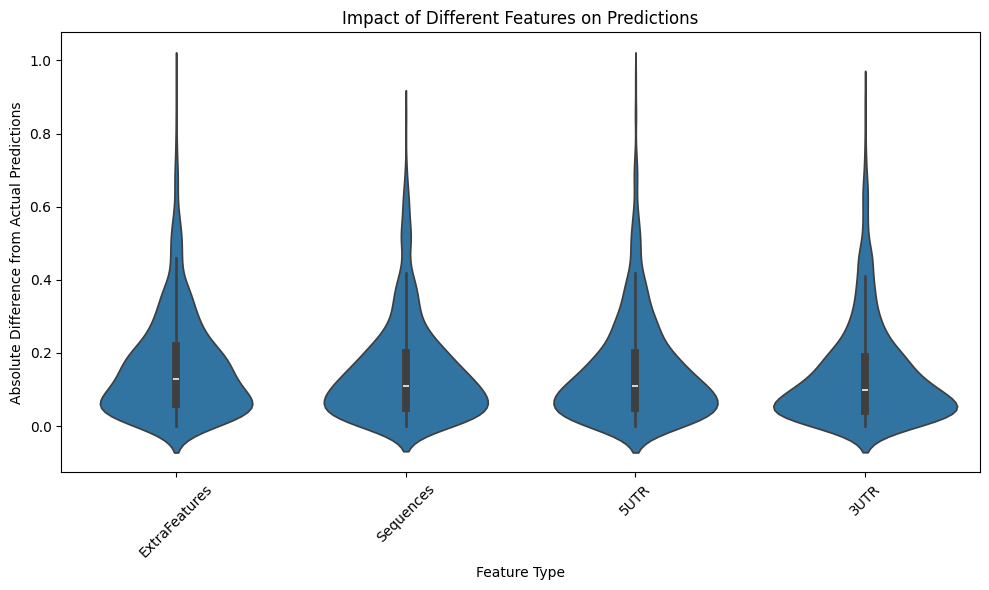

In [12]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_extraFeatures = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_extraFeatures) + list(impact_sequences) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['Sequences'] * len(impact_sequences) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# Calculate impacts (reusing the calculations from cell 13 but with absolute values)
impact_extraFeatures = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Store impacts in a dictionary for easier access
impacts = {
    'ExtraFeatures': impact_extraFeatures,
    'Sequences': impact_sequences,
    '5UTR': impact_5UTR,
    '3UTR': impact_3UTR
}

# Kruskal-Wallis test (non-parametric ANOVA)
print("Kruskal-Wallis Test (overall significance):")
h_stat, p_value = kruskal(*impacts.values())
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

print("\n" + "="*50)
print("Pairwise Mann-Whitney U Tests:")
print("="*50)

# Pairwise comparisons using Mann-Whitney U test
feature_names = list(impacts.keys())
for i, feature1 in enumerate(feature_names):
    for j, feature2 in enumerate(feature_names[i+1:], i+1):
        u_stat, p_val = mannwhitneyu(impacts[feature1], impacts[feature2], alternative='two-sided')
        print(f"{feature1} vs {feature2}:")
        print(f"  U-statistic: {u_stat:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
        print()

Kruskal-Wallis Test (overall significance):
H-statistic: 19.2723
p-value: 0.0002
Significant: Yes

Pairwise Mann-Whitney U Tests:
ExtraFeatures vs Sequences:
  U-statistic: 438099.5000
  p-value: 0.0184
  Significant: Yes

ExtraFeatures vs 5UTR:
  U-statistic: 436738.5000
  p-value: 0.0143
  Significant: Yes

ExtraFeatures vs 3UTR:
  U-statistic: 460520.5000
  p-value: 0.0000
  Significant: Yes

Sequences vs 5UTR:
  U-statistic: 413535.0000
  p-value: 0.8747
  Significant: No

Sequences vs 3UTR:
  U-statistic: 437426.5000
  p-value: 0.0370
  Significant: Yes

5UTR vs 3UTR:
  U-statistic: 432742.0000
  p-value: 0.0603
  Significant: No



In [28]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_extraFeatures = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = (merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_extraFeatures) + list(impact_sequences) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['Sequences'] * len(impact_sequences) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})


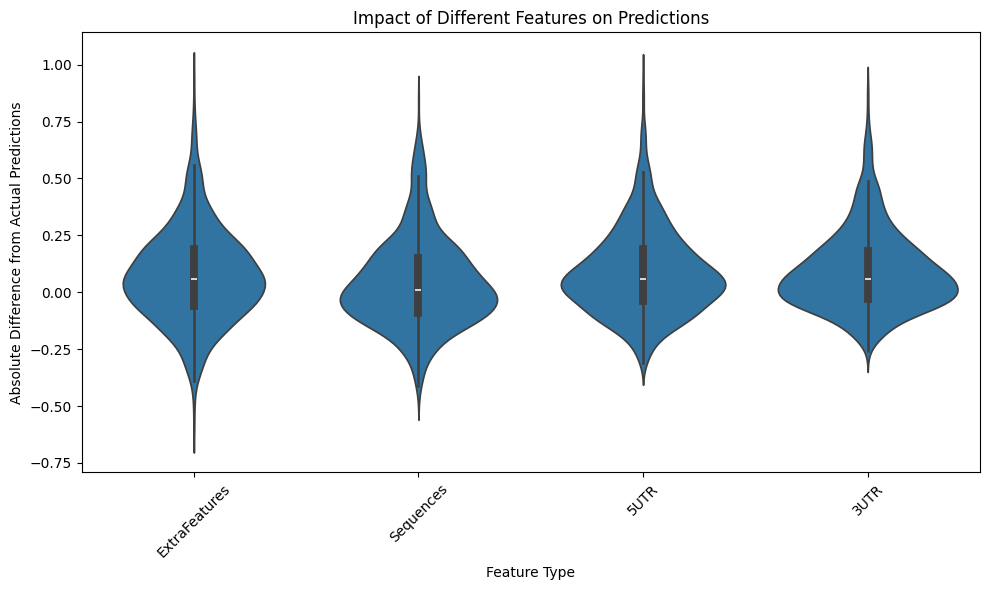

In [20]:

# Create swarm plot
plt.figure(figsize=(10, 6))
#sns.swarmplot(data=plot_data, x='Feature', y='Impact', size=3)
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import os
import pickle

os.chdir('../..')

In [11]:
importance = pickle.load(open('output/importance/shap.pkl', 'rb'))
for imp in importance:
    imp.scores *= len(imp.scores) # this makes the scores comparable between samples of different lengths
abs_values = [float(abs(min(sample.scores))) for sample in importance] + [float(abs(max(sample.scores))) for sample in importance]

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [29]:
print(max(abs_values))
print(np.max(np.array(abs_values)[np.array(abs_values) < 43]))
print(np.max(np.array(abs_values)[np.array(abs_values) < 26]))
print(np.max(np.array(abs_values)[np.array(abs_values) < 14]))
print(np.array(abs_values)[np.array(abs_values) >= 10])
print(np.array(abs_values)[np.array(abs_values) >= 8.727637123988798])

43.96833557020072
26.790177751857232
14.906927818897127
12.783238865184979
[26.79017775 10.59395877 11.57401823 43.96833557 14.90692782 11.19319343
 10.27903447 10.16239664 10.26155065 10.23771394 10.97094407 10.3656599
 10.47682008 10.31937521 12.78323887 14.5425812  11.5691156  10.90390334
 12.03247716 10.81582816]
[26.79017775 10.59395877 11.57401823  8.87802378 43.96833557  8.84012966
 14.90692782 11.19319343 10.27903447  8.95733097 10.16239664 10.26155065
 10.23771394 10.97094407  9.70368114 10.3656599  10.47682008 10.31937521
 12.78323887 14.5425812  11.5691156   9.86028874 10.90390334 12.03247716
 10.81582816  9.46776119  9.29761682]


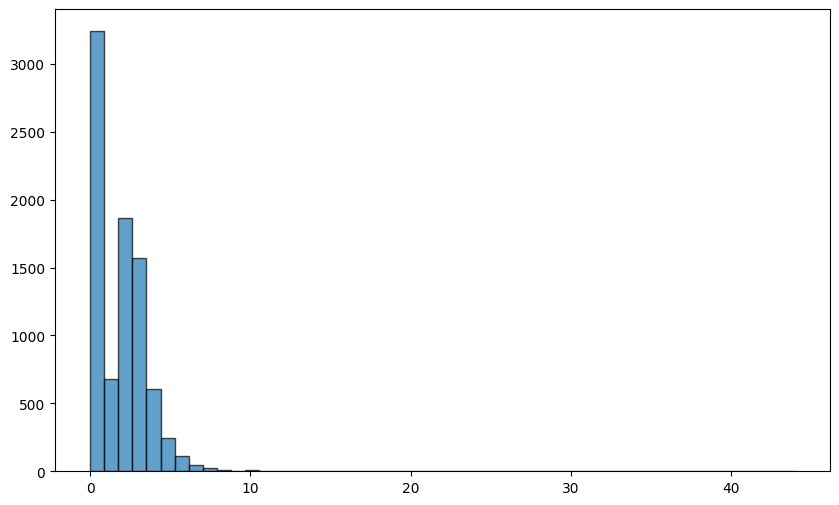

In [16]:
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

# Create combination histogram and density plot
plt.figure(figsize=(10, 6))

# Create histogram with density curve
plt.hist(abs_values, bins=50, alpha=0.7, edgecolor='black')
plt.show()


In [28]:
print(np.std(abs_values))
print(np.mean(abs_values))
print(np.mean(abs_values) + 5 * np.std(abs_values))
print(np.mean(abs_values) + 4 * np.std(abs_values))

1.719296765120718
1.8504500635059258
10.446933889109516
8.727637123988798


In [ ]:

# Add density curve
density = gaussian_kde(abs_values)
xs = np.linspace(min(abs_values), max(abs_values), 200)
plt.plot(xs, density(xs), 'r-', linewidth=2, label='Density')

plt.xlabel('Absolute SHAP Values')
plt.ylabel('Density')
plt.title('Distribution of Absolute SHAP Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some basic statistics
print(f"Mean: {np.mean(abs_values):.4f}")
print(f"Median: {np.median(abs_values):.4f}")
print(f"Standard deviation: {np.std(abs_values):.4f}")
print(f"Min: {np.min(abs_values):.4f}")
print(f"Max: {np.max(abs_values):.4f}")